In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='tenx_10K_pbmc-v1_atacseq',
    destination='scarf_datasets'
)

In [3]:
reader = scarf.CrH5Reader(f'{dataset}/data.h5')
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'{dataset}/data.zarr',
)
writer.dump(batch_size=1000)

In [5]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4
)

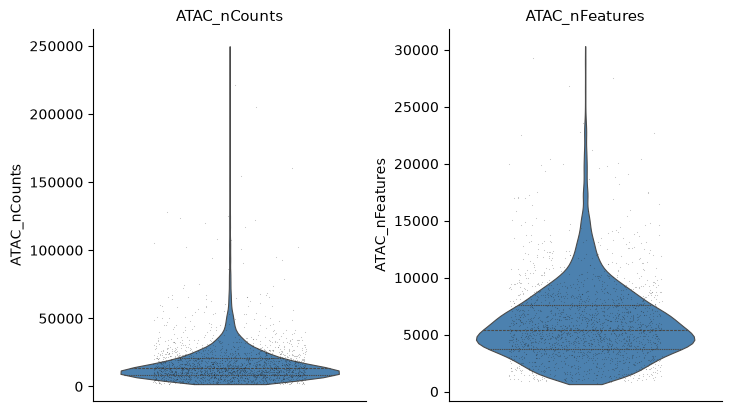

In [6]:
qc_cols = [
    c for c in ('ATAC_nCounts', 'ATAC_nFeatures')
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

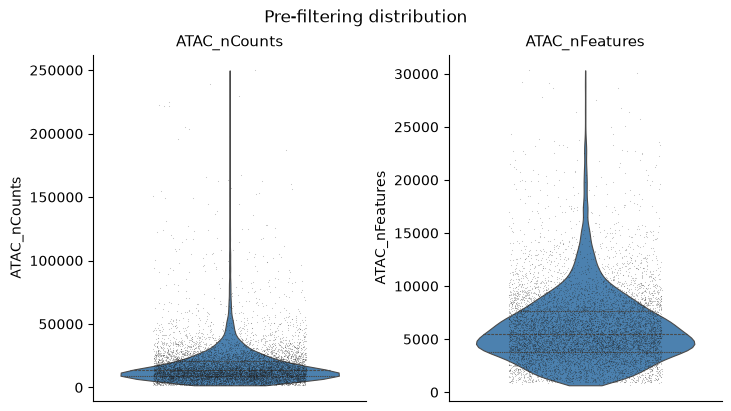

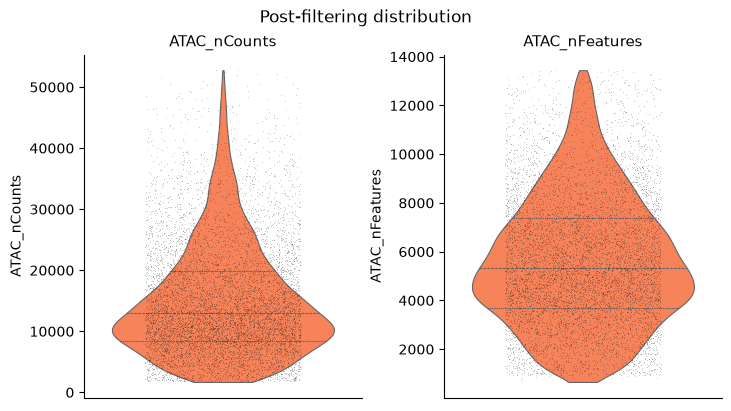

In [7]:
ds.auto_filter_cells(show_qc_plots=True)

In [8]:
ds.mark_prevalent_peaks(top_n=25000)

In [9]:
ds.ATAC.feats.head()

,I,ids,names,nCells,I__prevalent_peaks,dropOuts,stats_I_prevalence
0,True,chr1:565107-565550,chr1:565107-565550,83,False,8645,0.206181
1,True,chr1:569174-569639,chr1:569174-569639,199,False,8529,0.350725
2,True,chr1:713460-714823,chr1:713460-714823,2486,True,6242,1.993573
3,True,chr1:752422-753038,chr1:752422-753038,432,True,8296,0.680701
4,True,chr1:762106-763359,chr1:762106-763359,1878,True,6850,1.570790


In [10]:
ds.run_normalization(feat_key='prevalent_peaks')
ds.run_lsi(dims=50, skip_first=True)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=21)
ds.build_connectivity_map()

ds.load_graph()

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 176946 stored elements and shape (8426, 8426)>

In [11]:
ds.run_umap(
    n_epochs=500,
    min_dist=0.1, 
    spread=1, 
    parallel=True
)

In [12]:
ds.run_leiden_clustering(resolution=0.6)

In [13]:
ds.cells.to_pandas_dataframe(
    ['ATAC_UMAP1', 'ATAC_UMAP2', 'ATAC_leiden_cluster']
).head()

,ATAC_UMAP1,ATAC_UMAP2,ATAC_leiden_cluster
0,-2.442605,-11.617185,1
1,-4.094013,-14.420713,5
2,-4.815010,7.403503,9
3,NaN,NaN,-1
4,-2.194108,-10.847852,2


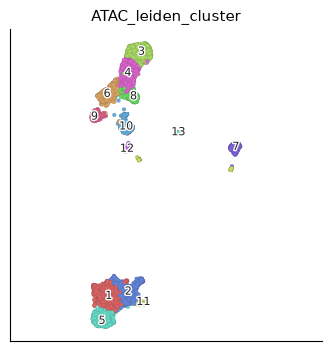

In [14]:
ds.plots.embedding(
    layout_key='ATAC_UMAP',
    color_by='ATAC_leiden_cluster',
)

In [15]:
annotations = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='annotations',
    destination='scarf_datasets'
)

In [16]:
ds.add_melded_assay(
    from_assay='ATAC',
    external_bed_fn=f'{annotations}/human_GRCh37_gencode_v38_gene_body.bed.gz',
    peaks_col='ids',
    renormalization=False,
    assay_label='GeneScores',
    assay_type='RNA'
)

In [17]:
ds

DataStore has 8426 (8728) cells with 2 assays: ATAC GeneScores
   Cell metadata:
            'I', 'ids', 'names', 'GeneScores_percentRibo', 'ATAC_UMAP2', 
            'GeneScores_percentMito', 'ATAC_leiden_cluster', 'ATAC_nFeatures', 'ATAC_nCounts', 'GeneScores_nCounts', 
            'GeneScores_nFeatures', 'ATAC_UMAP1'
   ATAC assay has 86049 (89796) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__prevalent_peaks', 
            'dropOuts'
   GeneScores assay has 28357 (62446) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

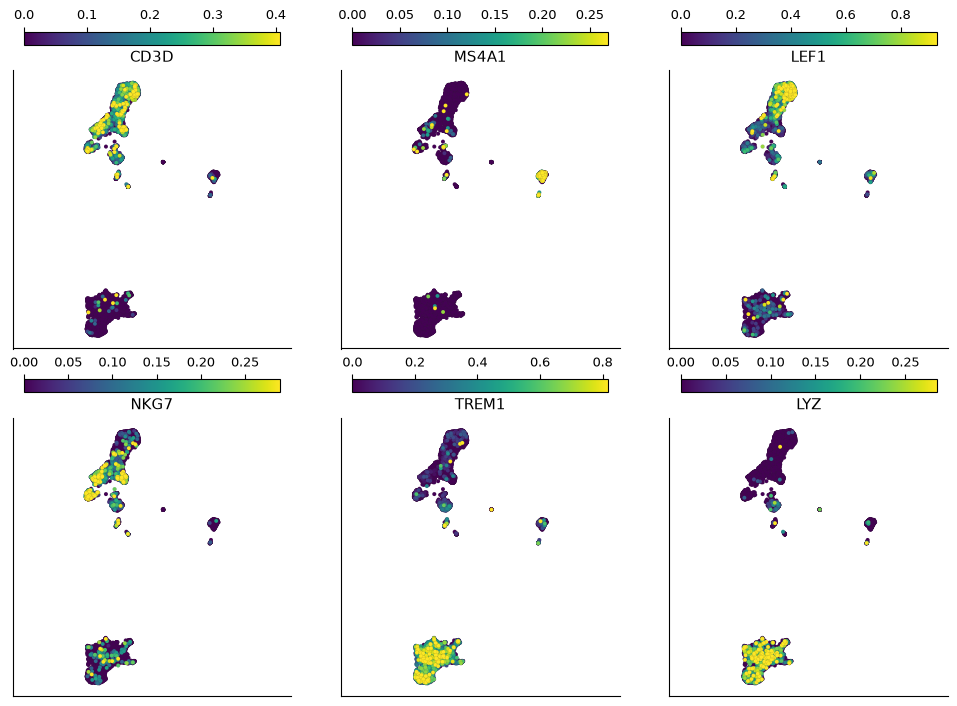

In [18]:
ds.plots.embedding(
    layout_key='ATAC_UMAP',
    from_assay='GeneScores',
    color_by=['CD3D', 'MS4A1', 'LEF1', 'NKG7', 'TREM1', 'LYZ'],
    clip_fraction=0.01,
    n_columns=3,
    sort_values=True,
)